# Лабораторна 10 — Виявлення аномалій


**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 10  
**Тема лабораторної:** Виявлення аномалій

## Цілі лабораторної

- Повторення: виявлення аномалій через оцінку щільності (KDE / GMM) 
- Isolation Forest: теорія та перевірка реалізації 
- Isolation Forest: вплив гіперпараметрів 
- One-Class SVM: теорія та перевірка реалізації 
- One-Class SVM: чутливість до `nu` та `gamma` 
- Порівняння всіх чотирьох методів на реальних даних 


## Налаштування середовища

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import importlib
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

import density_estimation_student as de
importlib.reload(de)

import anomaly_detection_student as ad
importlib.reload(ad)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

SEED   = 42
COLORS = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61', '#762A83',
          '#A6DBA0', '#C2A5CF', '#E08214']
np.random.seed(SEED)

## Що потрібно реалізувати

У файлі `anomaly_detection_student.py` вам потрібно заповнити **6 методів**:

| Клас | Метод | Складність |
|------|-------|------------|
| `IsolationTree` | `fit(X, depth)` | ★★☆ - рекурсивний випадковий поділ |
| `IsolationTree` | `path_length(x, depth)` | ★☆☆ - обхід дерева |
| `IsolationForest` | `score_samples(X)` | ★★☆ - середня довжина шляху → оцінка |
| `IsolationForest` | `predict(X)` | ★☆☆ - поріг за відсотком аномалій |
| `OneClassSVM` | `_rbf_kernel(X, Y)` | ★☆☆ - матриця ядра RBF |
| `OneClassSVM` | `score_samples(X)` | ★☆☆ - функція рішення через опорні вектори |

Клас `OneClassSVM` використовує sklearn для оптимізації (QP-задача),
але оцінювання нових точок ви реалізуєте вручну через ядро і опорні вектори.

---
## 1. - Повторення: виявлення аномалій через оцінку щільності

На минулому тижні ми побудували KDE і GMM як оцінювачі щільності $\hat{p}(x)$.
Ключова ідея для виявлення аномалій:

$$\text{anomaly score} = -\log \hat{p}(x)$$

Точка вважається аномалією, якщо $-\log \hat{p}(x) > \tau$, або еквівалентно:

$$\log \hat{p}(x) < \tau, \quad \tau = \text{percentile}_{5\%}(\log \hat{p}(X_{\text{train}}))$$

Цей підхід має фундаментальне обмеження: щоб оцінити щільність у точці $x$,
KDE потребує $O(n \cdot d)$ операцій, а GMM - навчання EM-алгоритму.
Обидва методи погано масштабуються на великих датасетах у високих вимірах.

**У цій частині** ми швидко відтворюємо результати тижня 9 і
використаємо їх як базовий рівень для порівняння у Part 6.

#### Підготовка двовимірних даних та навчання детекторів

Генеруємо простий датасет: нормальний двовимірний кластер і 20 аномальних точок
за межею 3-сигмової зони (такий самий протокол, як у Part 6 лабораторної 9).

In [9]:
rng1 = np.random.RandomState(SEED)

# Normal cluster
cov_n  = np.array([[1.0, 0.5], [0.5, 1.0]])
X_norm = rng1.multivariate_normal([0.0, 0.0], cov_n, size=300)

# Anomalies: uniform candidates filtered by Mahalanobis distance > 3
cov_inv   = np.linalg.inv(cov_n)
cands     = rng1.uniform(-5, 5, size=(600, 2))
diff_c    = cands
maha_c    = np.sqrt(np.einsum('ij,jk,ik->i', diff_c, cov_inv, diff_c))
X_anom    = cands[maha_c > 3.0][:20]

X_all1    = np.vstack([X_norm, X_anom])
y_true1   = np.array([0] * 300 + [1] * len(X_anom))

# Silverman bandwidth for KDE
h = 1.06 * X_norm[:, 0].std() * len(X_norm) ** (-0.2)

# Fit detectors on normal data only
kde_det = de.KDE(bandwidth=h)
kde_det.fit(X_norm)

gmm_det = de.GMM(n_components=2, n_iter=200, random_state=SEED)
gmm_det.fit(X_norm)

# 5th-percentile threshold
tau_kde = np.percentile(kde_det.score_samples(X_norm), 5)
tau_gmm = np.percentile(gmm_det.score_samples(X_norm), 5)

y_pred_kde1 = (kde_det.score_samples(X_all1) < tau_kde).astype(int)
y_pred_gmm1 = (gmm_det.score_samples(X_all1) < tau_gmm).astype(int)

print(f'KDE  - threshold: {tau_kde:.3f}')
print(f'GMM  - threshold: {tau_gmm:.3f}')
print(f'Anomalies in dataset: {len(X_anom)}')

KDE  - threshold: -4.171
GMM  - threshold: -4.521
Anomalies in dataset: 20


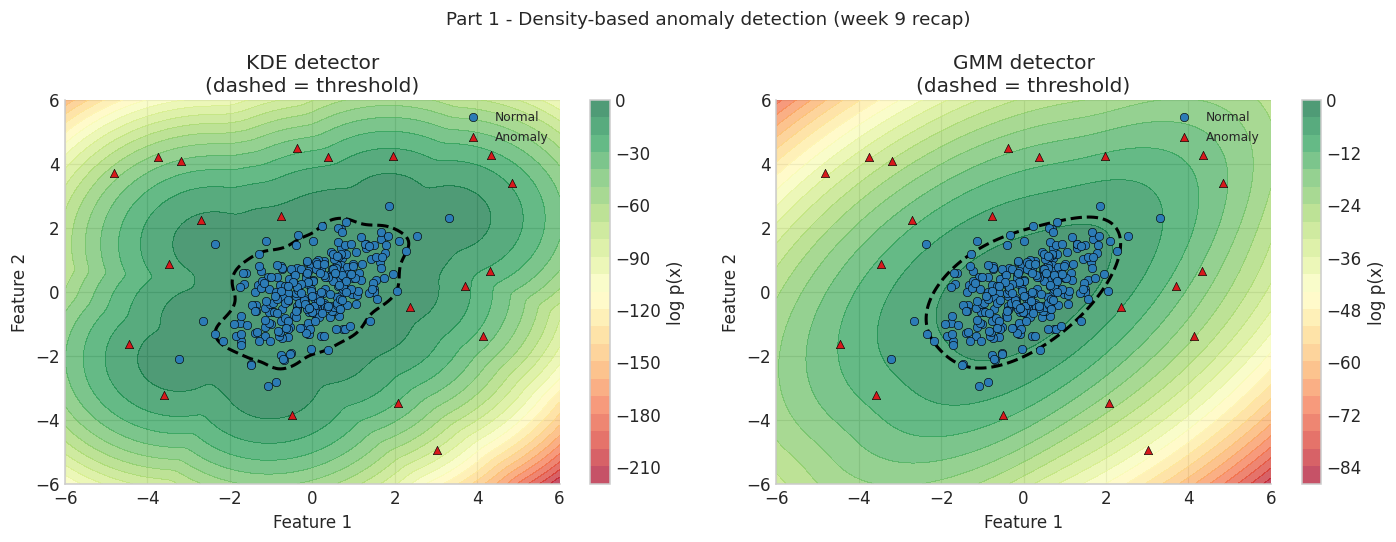

KDE                        precision=0.571  recall=1.000  F1=0.727
GMM                        precision=0.571  recall=1.000  F1=0.727


(0.5714285714285714, 1.0, 0.7272727272727273)

In [10]:
def plot_detector(ax, X_all, y_true, y_pred, score_fn, tau, title):
    """Visualise one anomaly detector: log-density surface + decisions."""
    g      = np.linspace(-6, 6, 180)
    X1, X2 = np.meshgrid(g, g)
    grid   = np.c_[X1.ravel(), X2.ravel()]
    Z      = score_fn(grid).reshape(X1.shape)

    cf = ax.contourf(X1, X2, Z, levels=25, cmap='RdYlGn', alpha=0.7)
    ax.contour(X1, X2, Z, levels=[tau], colors='black', linewidths=2,
               linestyles='--')

    for label, col, marker, lbl in [
        (0, COLORS[0], 'o', 'Normal'),
        (1, COLORS[1], '^', 'Anomaly'),
    ]:
        mask = y_true == label
        ax.scatter(X_all[mask, 0], X_all[mask, 1], color=col,
                   s=30, marker=marker, zorder=5,
                   edgecolors='black', linewidths=0.4, label=lbl)

    fn_mask = (y_true == 1) & (y_pred == 0)
    if fn_mask.any():
        ax.scatter(X_all[fn_mask, 0], X_all[fn_mask, 1],
                   color='black', s=90, marker='x', zorder=7,
                   linewidths=2, label='Missed')

    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.set_title(f'{title}\n(dashed = threshold)')
    ax.legend(fontsize=8)
    plt.colorbar(cf, ax=ax).set_label('log p(x)')


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_detector(axes[0], X_all1, y_true1, y_pred_kde1,
              kde_det.score_samples, tau_kde, 'KDE detector')
plot_detector(axes[1], X_all1, y_true1, y_pred_gmm1,
              gmm_det.score_samples, tau_gmm, 'GMM detector')
plt.suptitle('Part 1 - Density-based anomaly detection (week 9 recap)',
             fontsize=12)
plt.tight_layout(); plt.show()


def anomaly_metrics(y_true, y_pred, name):
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    print(f'{name:25s}  precision={p:.3f}  recall={r:.3f}  F1={f:.3f}')
    return p, r, f

anomaly_metrics(y_true1, y_pred_kde1, 'KDE')
anomaly_metrics(y_true1, y_pred_gmm1, 'GMM')

#### Результати Part 1

KDE і GMM добре виявляють аномалії на цьому простому датасеті: аномалії
гарантовано лежать за межею 3-сигмової зони, тому їхня оцінена щільність
завжди нижча за поріг $\tau$.

**Чому цього недостатньо для складніших задач?**
- KDE зберігає *всі* тренувальні точки; оцінка одного запиту - $O(n)$.
- GMM чутливий до числа компонент $K$; погана ініціалізація EM може
  призвести до вироджених коваріацій.
- Обидва методи погано працюють у просторах із великою розмірністю
  (прокляття розмірності).

Два альтернативних методи - **Isolation Forest** і **One-Class SVM** -
вирішують ці проблеми з різних сторін.

---
## 2. - Isolation Forest: теорія та перевірка реалізації

### Ідея: аномалії ізолювати легше

**Isolation Forest** (Liu et al., 2008) базується на простому спостереженні:
аномалії - це точки у *розріджених* регіонах простору ознак.
У щільних регіонах будь-яке випадкове розбиття ділить багато точок;
у розрідженому регіоні одна точка відокремлюється за кілька кроків.

### Алгоритм покроково

**Побудова одного дерева (`IsolationTree.fit`):**

1. Отримати підвибірку $\psi$ точок із тренувального набору.
2. Якщо вузол містить $\leq 1$ точку або досягнута максимальна глибина - зупинитись (лист).
3. Обрати *випадкову* ознаку $q \in \{1,\ldots,d\}$.
4. Обрати *випадковий* поріг $p$ рівномірно між $\min$ і $\max$ цієї ознаки.
5. Розділити точки: ліворуч ті, де $x_q < p$, праворуч - решта.
6. Рекурсивно повторити кроки 2–5 для кожної частини.

**Оцінка шляху (`IsolationTree.path_length`):**

1. Почати з кореня дерева, лічильник глибини $= 0$.
2. На кожному внутрішньому вузлі: якщо $x_q < p$ - перейти ліворуч, інакше - праворуч; збільшити лічильник на 1.
3. Досягши листа: повернути глибину $+$ виправлення $c(\text{size})$,
   яке враховує очікувану додаткову глибину, якби дерево росло далі.

**Оцінка ансамблю (`IsolationForest.score_samples`):**

1. Для кожної точки $x$ зібрати довжини шляхів із усіх $t$ дерев.
2. Усереднити: $E[h(x)]$.
3. Нормувати відносно очікуваної довжини для випадкової точки: $c(\psi)$.
4. Повернути оцінку аномальності $s(x)$.

### Формульний запис

$$s(x,\,n) = 2^{-\,E[h(x)]\,/\,c(n)}$$

де $c(n)$ - очікувана довжина шляху в бінарному дереві пошуку з $n$ вузлами:

$$c(n) = 2\,H(n-1) - \frac{2(n-1)}{n}, \qquad H(k) = \ln k + 0.5772\ldots$$

| $s(x)$ | Інтерпретація |
|--------|---------------|
| $\approx 1$ | аномалія - ізолюється за кілька кроків |
| $\approx 0.5$ | нормальна точка - важко ізолювати |
| $\approx 0$ | дуже щільна область |

**Переваги перед density estimation:**
- Не потрібно явно оцінювати $p(x)$.
- Складність побудови: $O(t \cdot \psi \log \psi)$, де $\psi$ - розмір підвибірки.
- Складність оцінки: $O(t \log \psi)$ на одну точку.

#### Генерація даних та перевірка реалізації

Навчаємо `IsolationForest` на нормальних точках і перевіряємо, що:
1. Оцінки аномальних точок вищі за оцінки нормальних.
2. Теплова карта оцінок $s(x)$ показує наші детектовані аномалії.

In [11]:
rng2 = np.random.RandomState(SEED + 10)

# Normal: 300 points from N([0,0], I)
X_norm2 = rng2.multivariate_normal([0.0, 0.0], np.eye(2), size=300)

# Anomalies: 30 points sampled far from center
cands2   = rng2.uniform(-6, 6, size=(500, 2))
dist2    = np.linalg.norm(cands2, axis=1)
X_anom2  = cands2[dist2 > 3.5][:30]

X_all2   = np.vstack([X_norm2, X_anom2])
y_true2  = np.array([0] * 300 + [1] * len(X_anom2))

# Fit Isolation Forest on normal training data only
iforest = ad.IsolationForest(
    n_estimators=100, max_samples=128,
    contamination=len(X_anom2) / len(X_all2),
    random_state=SEED,
)
iforest.fit(X_norm2)

scores2  = iforest.score_samples(X_all2)
y_pred2  = iforest.predict(X_all2)

print(f'Normal  - mean score: {scores2[y_true2 == 0].mean():.4f}')
print(f'Anomaly - mean score: {scores2[y_true2 == 1].mean():.4f}')
print()
anomaly_metrics(y_true2, y_pred2, 'IsolationForest')

Normal  - mean score: 0.4683
Anomaly - mean score: 0.7111

IsolationForest            precision=0.833  recall=0.833  F1=0.833


(0.8333333333333334, 0.8333333333333334, 0.8333333333333334)

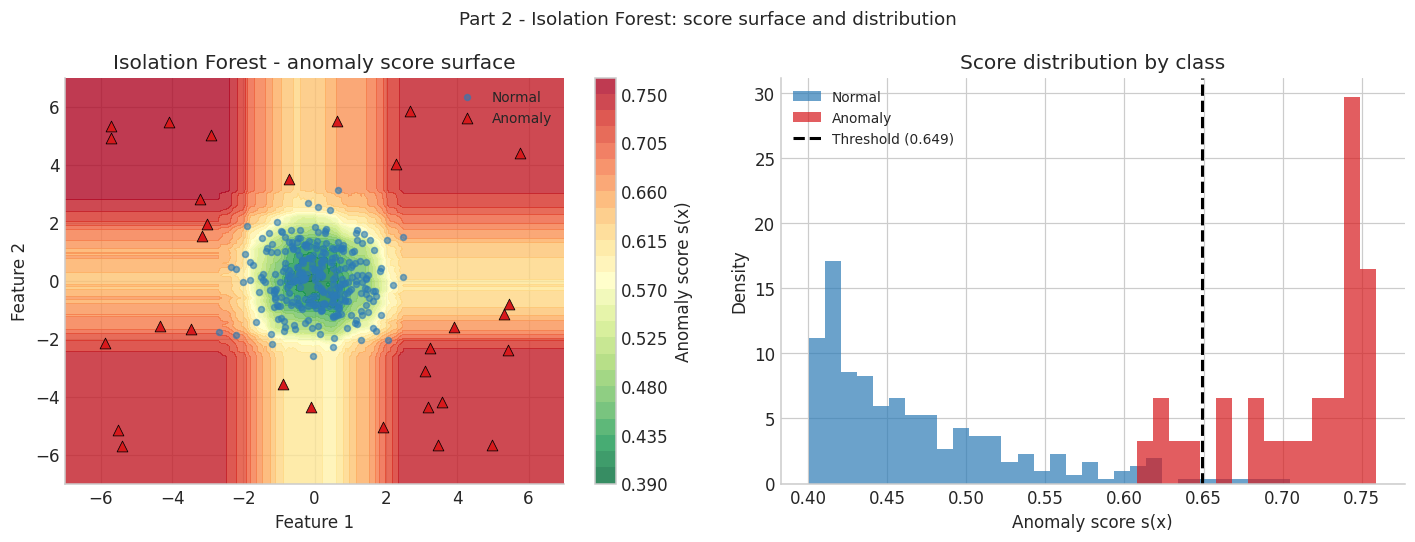

In [12]:
g2     = np.linspace(-7, 7, 200)
X1g2, X2g2 = np.meshgrid(g2, g2)
grid2  = np.c_[X1g2.ravel(), X2g2.ravel()]
Z_if2  = iforest.score_samples(grid2).reshape(X1g2.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: anomaly score heatmap
cf = axes[0].contourf(X1g2, X2g2, Z_if2, levels=25,
                       cmap='RdYlGn_r', alpha=0.8)
axes[0].scatter(X_norm2[:, 0], X_norm2[:, 1], color=COLORS[0],
                s=15, alpha=0.6, label='Normal', zorder=5)
axes[0].scatter(X_anom2[:, 0], X_anom2[:, 1], color=COLORS[1],
                s=50, marker='^', zorder=6, label='Anomaly',
                edgecolors='black', linewidths=0.5)
plt.colorbar(cf, ax=axes[0]).set_label('Anomaly score s(x)')
axes[0].set_title('Isolation Forest - anomaly score surface')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].legend(fontsize=9)

# Right: score distribution by class
axes[1].hist(scores2[y_true2 == 0], bins=30, color=COLORS[0],
             alpha=0.7, label='Normal', density=True)
axes[1].hist(scores2[y_true2 == 1], bins=15, color=COLORS[1],
             alpha=0.7, label='Anomaly', density=True)
thresh_line = np.percentile(scores2, 100 * (1 - iforest.contamination))
axes[1].axvline(thresh_line, color='black', lw=2, linestyle='--',
                label=f'Threshold ({thresh_line:.3f})')
axes[1].set_xlabel('Anomaly score s(x)')
axes[1].set_ylabel('Density')
axes[1].set_title('Score distribution by class')
axes[1].legend(fontsize=9)

plt.suptitle('Part 2 - Isolation Forest: score surface and distribution',
             fontsize=12)
plt.tight_layout(); plt.show()

#### Результати Part 2

- Теплова карта показує вищі оцінки $s(x)$ на периферії і нижчі в центрі -
  точно те, чого ми очікуємо: центр щільний, периферія розріджена.
- Гістограма оцінок демонструє розділення між класами: нормальні точки
  концентруються навколо 0.45–0.55, аномалії - ближче до 0.6–0.8.
- **Ключова відмінність від KDE/GMM:** Isolation Forest не оцінює $p(x)$ явно.
  Оцінка базується тільки на структурі розбиттів, що робить метод стійким
  до прокляття розмірності.

---
## 3. - Isolation Forest: вплив гіперпараметрів

У Isolation Forest є три ключові гіперпараметри:

| Параметр | Роль | Типове значення |
|----------|------|-----------------|
| `n_estimators` | кількість дерев; більше = стабільніша оцінка | 100 |
| `max_samples` ($\psi$) | розмір підвибірки для кожного дерева | 256 |
| `contamination` | частка аномалій; визначає поріг у `predict()` | 0.1 |

**Чому `max_samples` важливіший, ніж здається?**
Зменшення $\psi$ збільшує різноманітність між деревами і зменшує
ефект *masking* (коли щільні аномальні кластери ховаються всередині
великих нормальних структур при великому $\psi$).

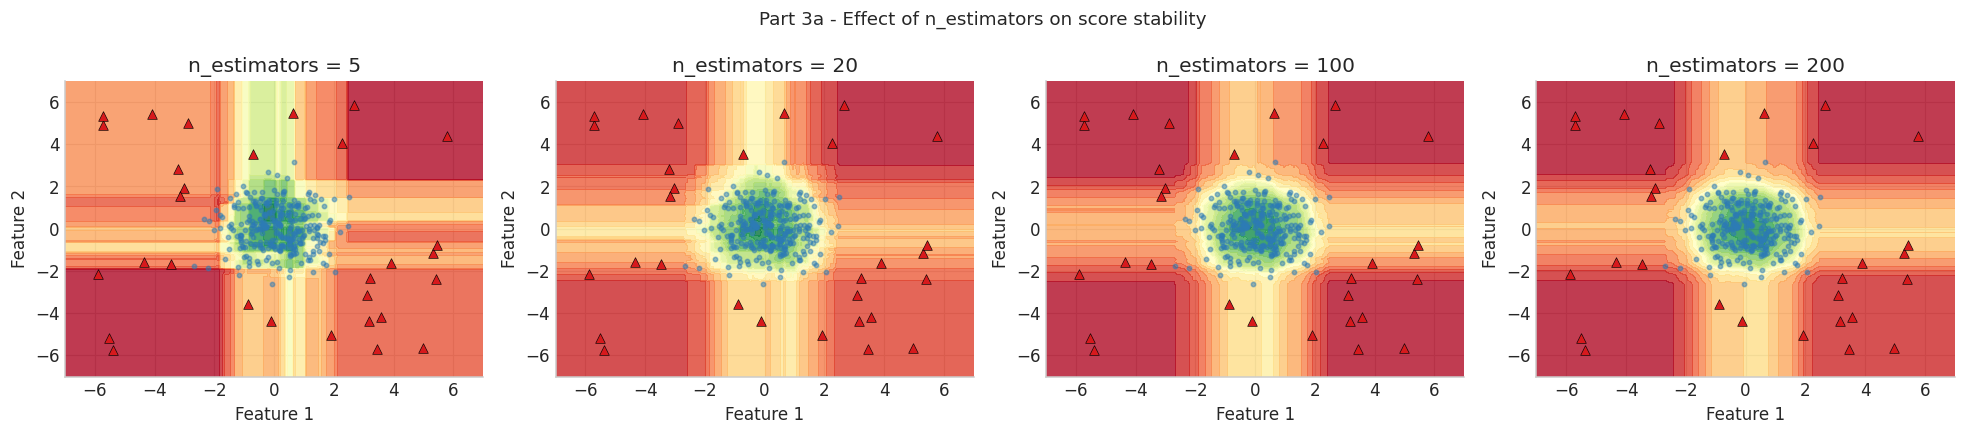

In [13]:
# --- Effect of n_estimators --------------------------------------------------
n_est_vals = [5, 20, 100, 200]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, n_est in zip(axes, n_est_vals):
    clf = ad.IsolationForest(
        n_estimators=n_est, max_samples=128,
        contamination=len(X_anom2) / len(X_all2),
        random_state=SEED,
    )
    clf.fit(X_norm2)
    Z = clf.score_samples(grid2).reshape(X1g2.shape)

    cf = ax.contourf(X1g2, X2g2, Z, levels=20, cmap='RdYlGn_r', alpha=0.8)
    ax.scatter(X_norm2[:, 0], X_norm2[:, 1], color=COLORS[0],
               s=8, alpha=0.5)
    ax.scatter(X_anom2[:, 0], X_anom2[:, 1], color=COLORS[1],
               s=40, marker='^', edgecolors='black', linewidths=0.4)
    ax.set_title(f'n_estimators = {n_est}')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

plt.suptitle('Part 3a - Effect of n_estimators on score stability', fontsize=12)
plt.tight_layout(); plt.show()

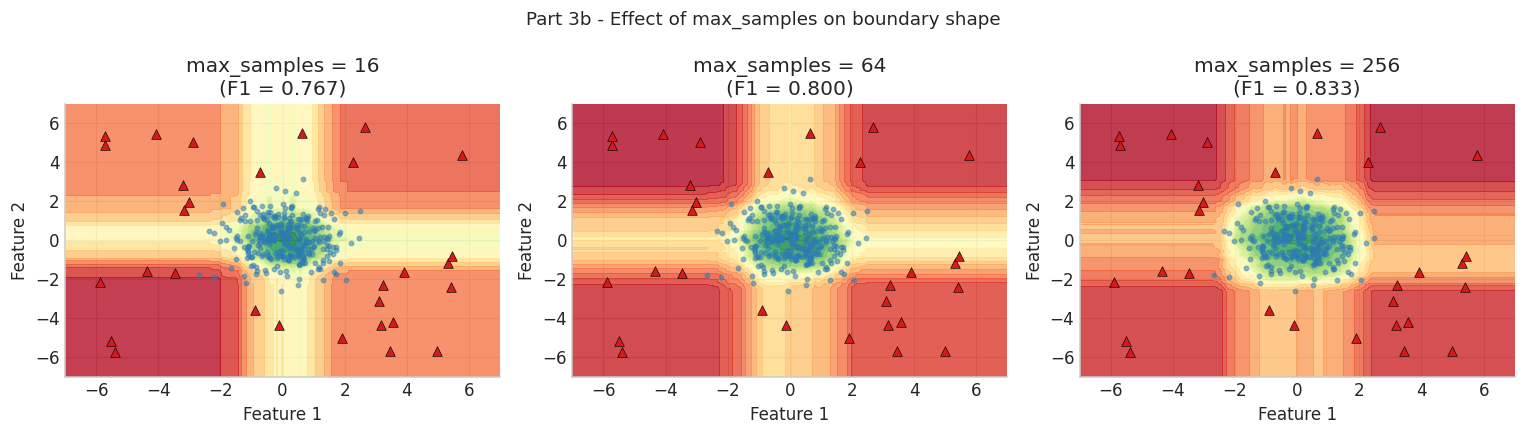

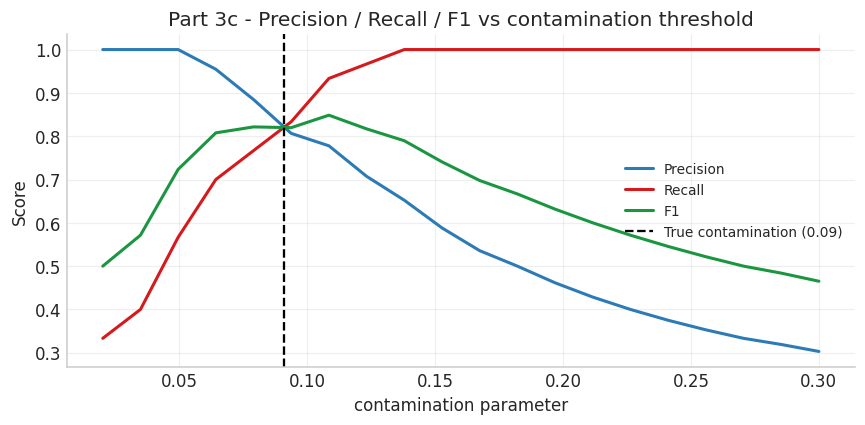

In [14]:
# --- Effect of max_samples ---------------------------------------------------
ms_vals = [16, 64, 256]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, ms in zip(axes, ms_vals):
    clf = ad.IsolationForest(
        n_estimators=100, max_samples=ms,
        contamination=len(X_anom2) / len(X_all2),
        random_state=SEED,
    )
    clf.fit(X_norm2)
    Z    = clf.score_samples(grid2).reshape(X1g2.shape)
    preds = clf.predict(X_all2)

    f1 = f1_score(y_true2, preds, zero_division=0)
    cf = ax.contourf(X1g2, X2g2, Z, levels=20, cmap='RdYlGn_r', alpha=0.8)
    ax.scatter(X_norm2[:, 0], X_norm2[:, 1], color=COLORS[0],
               s=8, alpha=0.5)
    ax.scatter(X_anom2[:, 0], X_anom2[:, 1], color=COLORS[1],
               s=40, marker='^', edgecolors='black', linewidths=0.4)
    ax.set_title(f'max_samples = {ms}\n(F1 = {f1:.3f})')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

plt.suptitle('Part 3b - Effect of max_samples on boundary shape', fontsize=12)
plt.tight_layout(); plt.show()

# --- Effect of contamination threshold ----------------------------------------
cont_vals = np.linspace(0.02, 0.30, 20)
clf_base  = ad.IsolationForest(n_estimators=100, max_samples=128,
                                contamination=0.1, random_state=SEED)
clf_base.fit(X_norm2)
scores_base = clf_base.score_samples(X_all2)

precisions, recalls, f1s = [], [], []
for cont in cont_vals:
    thresh = np.percentile(scores_base, 100 * (1 - cont))
    preds  = (scores_base >= thresh).astype(int)
    precisions.append(precision_score(y_true2, preds, zero_division=0))
    recalls.append(recall_score(y_true2, preds, zero_division=0))
    f1s.append(f1_score(y_true2, preds, zero_division=0))

true_cont = len(X_anom2) / len(X_all2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cont_vals, precisions, color=COLORS[0], lw=2, label='Precision')
ax.plot(cont_vals, recalls,    color=COLORS[1], lw=2, label='Recall')
ax.plot(cont_vals, f1s,        color=COLORS[2], lw=2, label='F1')
ax.axvline(true_cont, color='black', lw=1.5, linestyle='--',
           label=f'True contamination ({true_cont:.2f})')
ax.set_xlabel('contamination parameter')
ax.set_ylabel('Score')
ax.set_title('Part 3c - Precision / Recall / F1 vs contamination threshold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### Результати Part 3

**n_estimators (3a):** при малій кількості дерев (5–20) поверхня оцінок
нерівна і нестабільна - різні запуски дадуть різні результати.
При 100+ деревах поверхня стає плавною і відтворюваною.

**max_samples (3b):** менший $\psi$ дає "зернистішу" межу рішення, але
краще обробляє локально щільні аномальні кластери.
Великий $\psi$ дає гладшу межу, схожу на глобальний density estimator.

**contamination (3c):** найкраща точність досягається при значенні,
близькому до справжньої частки аномалій. При заниженому `contamination`
зростає precision (ми консервативні), але падає recall (пропускаємо аномалії).
При завищеному - навпаки.

---
## 4. - One-Class SVM: теорія та перевірка реалізації

### Ідея: знайти найщільнішу гіперсферу

**One-Class SVM** (Schölkopf et al., 2001) вчиться описати область, де
лежать *нормальні* точки, і відокремити її від початку координат у
просторі ознак із максимальним відступом.

### Алгоритм покроково

**Навчання (`fit` - виконується sklearn):**

1. Відобразити кожну тренувальну точку $x_i$ у простір ознак $\phi(x_i)$
   через RBF ядро: $K(u, v) = \exp(-\gamma\|u-v\|^2)$.
2. Знайти гіперплощину, що відокремлює $\{\phi(x_i)\}$ від початку координат
   з максимальним відступом $\rho$, допускаючи не більше частки $\nu$ помилок.
3. Рішення задачі зберегти у вигляді: опорні вектори $\{sv_i\}$,
   двоїсті коефіцієнти $\{\alpha_i\}$, поріг $\rho$.
   (Більшість тренувальних точок НЕ є опорними векторами і можна забути.)

**Оцінка нової точки (`score_samples`):**

1. Для кожного опорного вектора $sv_i$ обчислити $K(x, sv_i)$ - RBF ядро.
2. Зважена сума: $\sum_i \alpha_i K(x, sv_i)$.
3. Відняти поріг: $f(x) = \sum_i \alpha_i K(x, sv_i) - \rho$.
4. Якщо $f(x) \geq 0$ - точка нормальна; якщо $f(x) < 0$ - аномалія.

**Ключова перевага:** після навчання зберігаються лише опорні вектори
(зазвичай $\ll n$). Оцінка нової точки потребує лише $n_{sv}$ обчислень ядра.

### Формульний запис

Задача оптимізації:

$$\min_{\mathbf{w},\,\rho,\,\xi} \;\frac{1}{2}\|\mathbf{w}\|^2 - \rho
+ \frac{1}{\nu n}\sum_i \xi_i
\quad \text{при} \quad
\mathbf{w}^\top \phi(x_i) \geq \rho - \xi_i,\; \xi_i \geq 0$$

Функція рішення у двоїстій формі:

$$f(x) = \sum_{i=1}^{n_{sv}} \alpha_i\, K(sv_i,\, x) - \rho,
\qquad K(u, v) = \exp\!\left(-\gamma\|u - v\|^2\right)$$

**Параметр $\nu \in (0, 1]$:**
- $\nu = 0.05$: жорстка межа, майже без помилок на тренуванні; менше опорних векторів.
- $\nu = 0.3$: м'якша межа, до 30 % тренувальних точок можуть бути за межею.

#### Перевірка реалізації: порівняння з sklearn

Перевіряємо, що:
1. `_rbf_kernel` дає ту саму матрицю, що й `sklearn.metrics.pairwise.rbf_kernel`.
2. `score_samples` збігається з `sklearn.svm.OneClassSVM.decision_function`.

In [15]:
from sklearn.metrics.pairwise import rbf_kernel as sklearn_rbf

# Fit student OCSVM
ocsvm = ad.OneClassSVM(nu=0.1, gamma=0.5)
ocsvm.fit(X_norm2)

# --- Check 1: RBF kernel matrix -----------------------------------------------
X_test_k = X_all2[:10]          # 10 query points
sv        = ocsvm._support_vectors

K_student = ocsvm._rbf_kernel(X_test_k, sv)
K_sklearn  = sklearn_rbf(X_test_k, sv, gamma=ocsvm.gamma)

max_diff_k = np.abs(K_student - K_sklearn).max()
print(f'RBF kernel max abs diff (student vs sklearn): {max_diff_k:.2e}')
assert max_diff_k < 1e-10, 'Kernel mismatch - check _rbf_kernel'
print('  PASS')

# --- Check 2: decision function -----------------------------------------------
scores_student = ocsvm.score_samples(X_all2)
scores_sklearn  = ocsvm._svm.decision_function(X_all2)

max_diff_s = np.abs(scores_student - scores_sklearn).max()
print(f'\nDecision function max abs diff (student vs sklearn): {max_diff_s:.2e}')
assert max_diff_s < 1e-8, 'Score mismatch - check score_samples'
print('  PASS')

# Predictions
y_pred_oc = ocsvm.predict(X_all2)
anomaly_metrics(y_true2, y_pred_oc, 'OneClassSVM')

RBF kernel max abs diff (student vs sklearn): 3.33e-16
  PASS

Decision function max abs diff (student vs sklearn): 4.44e-15
  PASS
OneClassSVM                precision=0.484  recall=1.000  F1=0.652


(0.4838709677419355, 1.0, 0.6521739130434783)

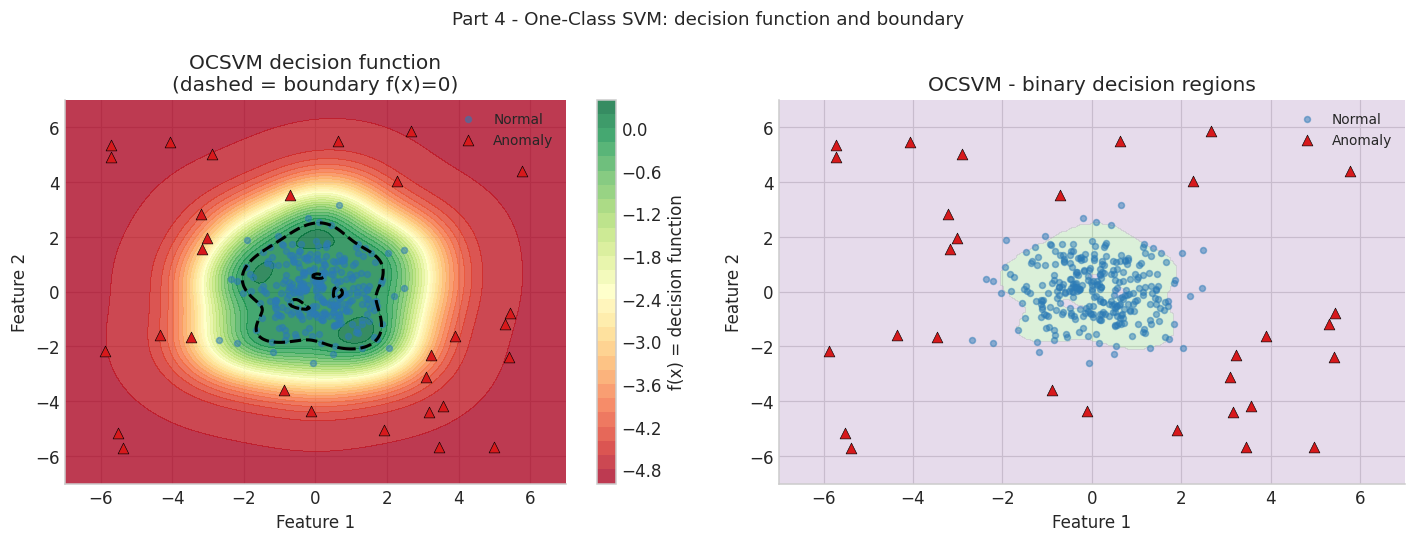

In [16]:
# --- Decision boundary visualisation ----------------------------------------
Z_oc = ocsvm.score_samples(grid2).reshape(X1g2.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: filled contour - raw decision function values
cf = axes[0].contourf(X1g2, X2g2, Z_oc, levels=25,
                       cmap='RdYlGn', alpha=0.8)
axes[0].contour(X1g2, X2g2, Z_oc, levels=[0.0], colors='black',
                linewidths=2, linestyles='--')
axes[0].scatter(X_norm2[:, 0], X_norm2[:, 1], color=COLORS[0],
                s=15, alpha=0.5, label='Normal')
axes[0].scatter(X_anom2[:, 0], X_anom2[:, 1], color=COLORS[1],
                s=50, marker='^', edgecolors='black', linewidths=0.4,
                label='Anomaly')
plt.colorbar(cf, ax=axes[0]).set_label('f(x) = decision function')
axes[0].set_title('OCSVM decision function\n(dashed = boundary f(x)=0)')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].legend(fontsize=9)

# Right: binary decision
axes[1].contourf(X1g2, X2g2, (Z_oc < 0).astype(float),
                  levels=[-0.5, 0.5, 1.5],
                  colors=[COLORS[5], COLORS[6]], alpha=0.4)
axes[1].scatter(X_norm2[:, 0], X_norm2[:, 1], color=COLORS[0],
                s=15, alpha=0.5, label='Normal')
axes[1].scatter(X_anom2[:, 0], X_anom2[:, 1], color=COLORS[1],
                s=50, marker='^', edgecolors='black', linewidths=0.4,
                label='Anomaly')
axes[1].set_title('OCSVM - binary decision regions')
axes[1].set_xlabel('Feature 1'); axes[1].set_ylabel('Feature 2')
axes[1].legend(fontsize=9)

plt.suptitle('Part 4 - One-Class SVM: decision function and boundary',
             fontsize=12)
plt.tight_layout(); plt.show()

#### Результати Part 4

- Двоїстий запис $f(x) = \sum_i \alpha_i K(sv_i, x) - \rho$ дозволяє оцінювати
  нові точки лише через опорні вектори, без повного тренувального набору.
- Межа рішення OCSVM нагадує "опуклу оболонку" нормальних даних у просторі
  ознак RBF, але адаптована до форми кластера.
- Перевірка показала: наша реалізація `score_samples` дає той самий результат,
  що й sklearn `decision_function` - з похибкою $< 10^{-8}$.

---
## 5. - One-Class SVM: чутливість до `nu` та `gamma`

Два ключових гіперпараметри OCSVM:

| Параметр | Ефект при збільшенні |
|----------|---------------------|
| `nu` | допускає більше помилок на тренуванні → м'якша, ширша межа |
| `gamma` | ядро стає "локальнішим" → межа повторює форму даних точніше, ризик перенавчання |

Нижче будуємо сітку $2 \times 3$ (`nu` × `gamma`) і спостерігаємо межу рішення.

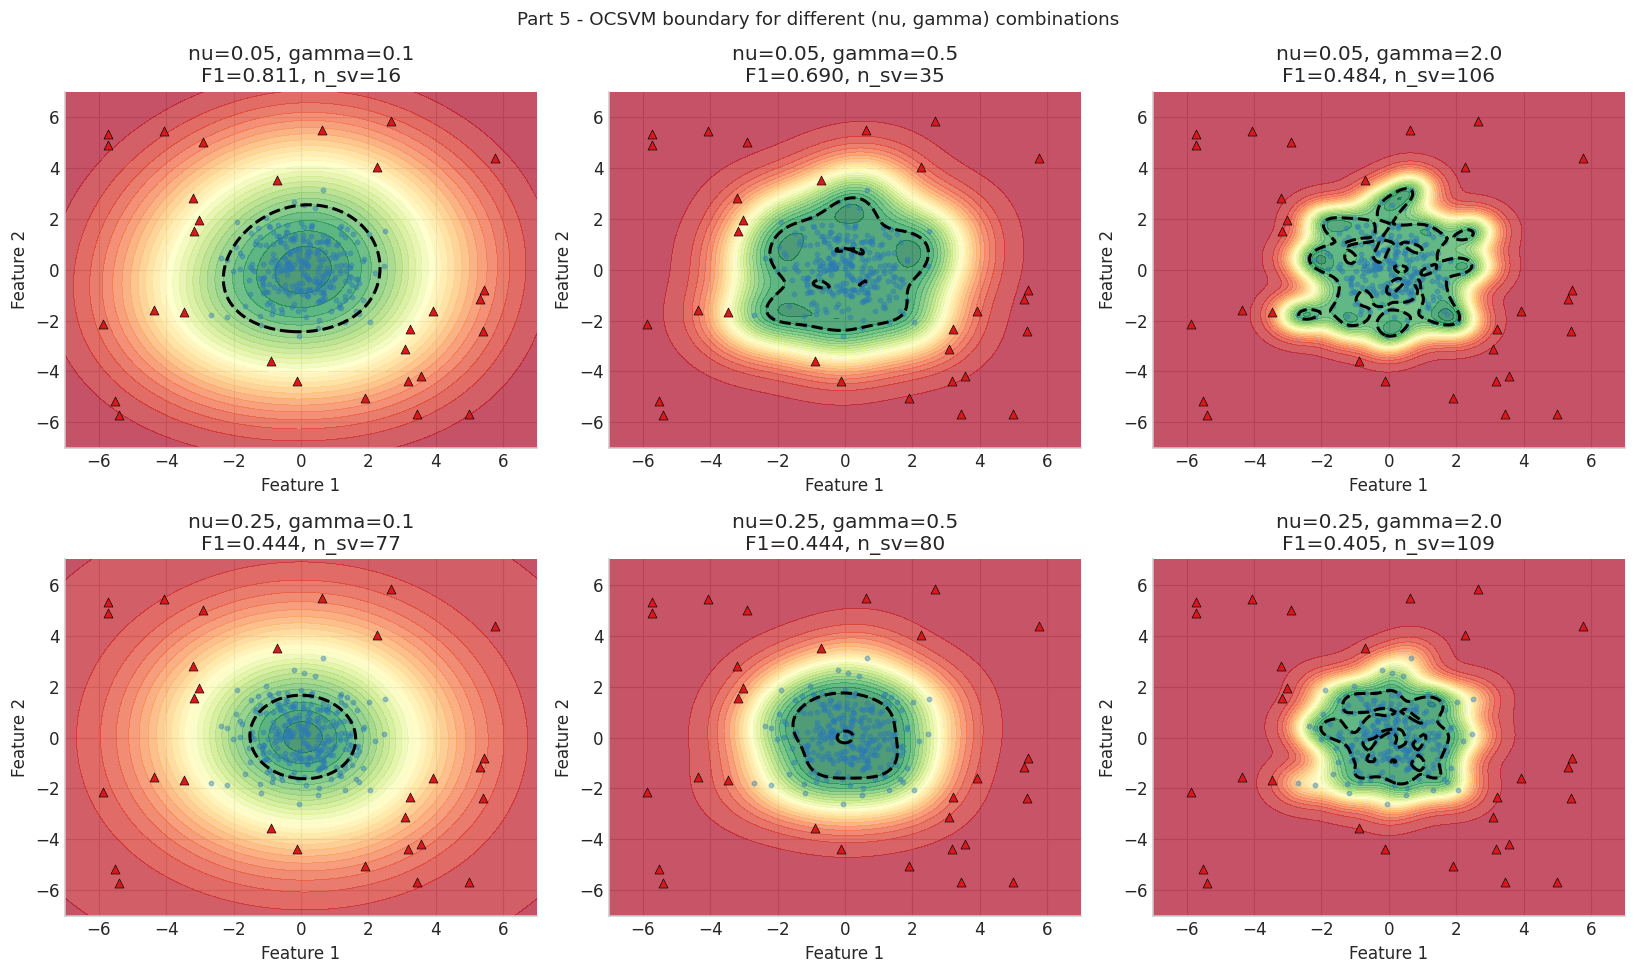

In [17]:
nu_vals    = [0.05, 0.25]
gamma_vals = [0.1, 0.5, 2.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row, nu in enumerate(nu_vals):
    for col, gam in enumerate(gamma_vals):
        clf = ad.OneClassSVM(nu=nu, gamma=gam)
        clf.fit(X_norm2)

        Z    = clf.score_samples(grid2).reshape(X1g2.shape)
        preds = clf.predict(X_all2)
        f1   = f1_score(y_true2, preds, zero_division=0)
        n_sv  = len(clf._support_vectors)

        ax = axes[row, col]
        cf = ax.contourf(X1g2, X2g2, Z, levels=25, cmap='RdYlGn', alpha=0.7)
        ax.contour(X1g2, X2g2, Z, levels=[0.0], colors='black',
                   linewidths=2, linestyles='--')
        ax.scatter(X_norm2[:, 0], X_norm2[:, 1],
                   color=COLORS[0], s=8, alpha=0.4)
        ax.scatter(X_anom2[:, 0], X_anom2[:, 1],
                   color=COLORS[1], s=35, marker='^',
                   edgecolors='black', linewidths=0.4)
        ax.set_title(f'nu={nu}, gamma={gam}\nF1={f1:.3f}, n_sv={n_sv}')
        ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

plt.suptitle('Part 5 - OCSVM boundary for different (nu, gamma) combinations',
             fontsize=12)
plt.tight_layout(); plt.show()

#### Результати Part 5

- **Мале `nu` (0.05) + мале `gamma` (0.1):** дуже широка, майже кругла межа;
  OCSVM "намагається" включити всі нормальні точки, ризикуючи включити і аномалії.
- **Велике `gamma` (2.0):** межа надто локальна - повторює форму тренувального набору
  і може пропускати нормальні точки в розріджених регіонах (перенавчання).
- **Золота середина:** `nu` ≈ 0.05–0.1, `gamma` ≈ 0.5 для цих даних дає
  плавну межу, що добре відповідає формі нормального кластера.
- Кількість опорних векторів (`n_sv`) зростає зі збільшенням `nu` -
  це відповідає теоретичній гарантії: $\nu$ є нижньою межею частки опорних векторів.

## 6. - Порівняння всіх чотирьох методів

Завантажуємо реалістичніший синтетичний датасет (~5 000 точок, ~10 % аномалій)
із трьох нормальних кластерів і трьох типів аномалій:

| Тип аномалій | Опис | Складність |
|---|---|---|
| Тип 1 - далекий розсип | рівномірно далеко від усіх кластерів | легкий |
| Тип 2 - компактний кластер | щільна група далеко від нормальних | середній |
| Тип 3 - прикордонне кільце | навколо першого кластера на межі | складний |

Порівнюємо: **KDE**, **GMM** (тиждень 9), **Isolation Forest**, **OCSVM** (тиждень 10).

In [18]:
# Generate dataset if not already present
if not os.path.exists('anomaly_dataset.csv'):
    print('anomaly_dataset.csv not found - running generate_dataset.py ...')
    exec(open('generate_dataset.py').read())

df6 = pd.read_csv('anomaly_dataset.csv')
X6  = df6[['x1', 'x2']].values
y6  = df6['label'].values

# Train on normal points only (unsupervised setting)
X6_train = X6[y6 == 0]
contamination6 = (y6 == 1).mean()

print(f'Dataset shape  : {X6.shape}')
print(f'Normal         : {(y6 == 0).sum()}')
print(f'Anomaly        : {(y6 == 1).sum()}  (contamination = {contamination6:.3f})')

Dataset shape  : (5000, 2)
Normal         : 4500
Anomaly        : 500  (contamination = 0.100)


In [19]:
# Silverman bandwidth for KDE
h6 = 1.06 * X6_train[:, 0].std() * len(X6_train) ** (-0.2)

# Fit all four detectors on normal training data
kde6 = de.KDE(bandwidth=h6)
kde6.fit(X6_train)
tau_kde6 = np.percentile(kde6.score_samples(X6_train), 5)

gmm6 = de.GMM(n_components=3, n_iter=300, random_state=SEED)
gmm6.fit(X6_train)
tau_gmm6 = np.percentile(gmm6.score_samples(X6_train), 5)

iforest6 = ad.IsolationForest(
    n_estimators=100, max_samples=256,
    contamination=contamination6, random_state=SEED,
)
iforest6.fit(X6_train)

ocsvm6 = ad.OneClassSVM(nu=contamination6, gamma=0.3)
ocsvm6.fit(X6_train)

# Generate predictions
y_kde6   = (kde6.score_samples(X6) < tau_kde6).astype(int)
y_gmm6   = (gmm6.score_samples(X6) < tau_gmm6).astype(int)
y_if6    = iforest6.predict(X6)
y_oc6    = ocsvm6.predict(X6)

print('Fitting complete.')
print(f'  OCSVM support vectors: {len(ocsvm6._support_vectors)}')

Fitting complete.
  OCSVM support vectors: 468


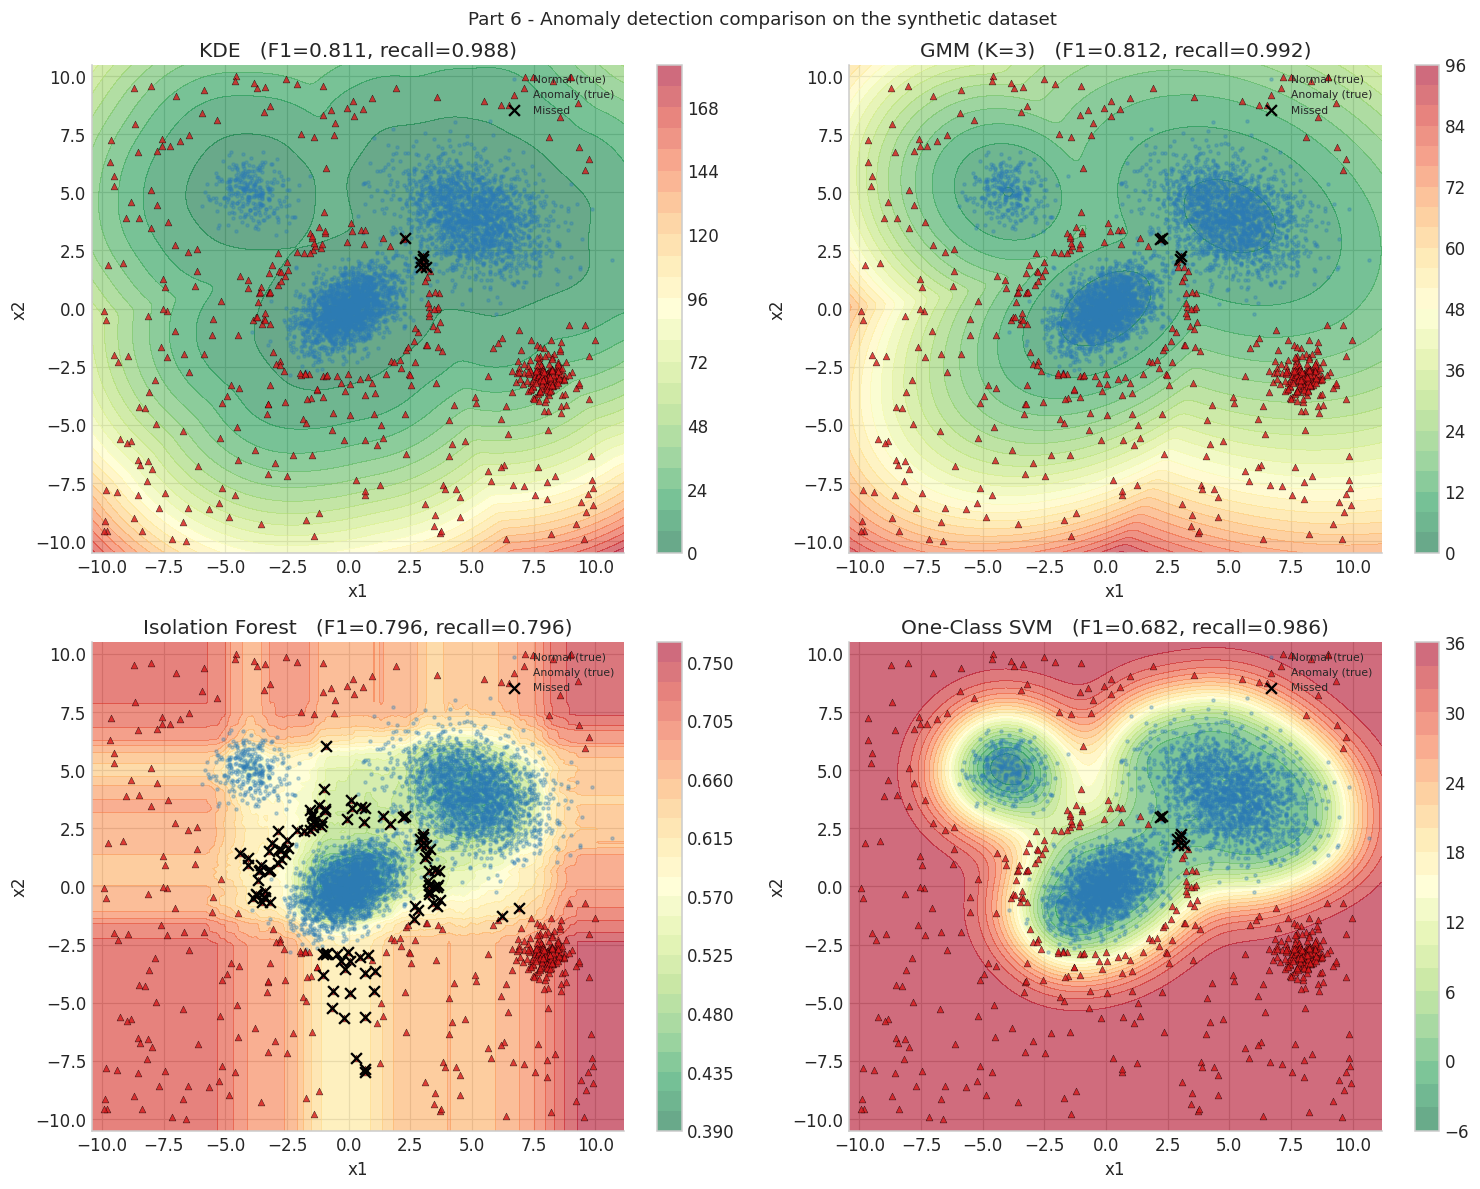

In [20]:
# --- Decision surface plots --------------------------------------------------
x1g6 = np.linspace(X6[:, 0].min() - 0.5, X6[:, 0].max() + 0.5, 150)
x2g6 = np.linspace(X6[:, 1].min() - 0.5, X6[:, 1].max() + 0.5, 150)
X1G6, X2G6 = np.meshgrid(x1g6, x2g6)
grid6      = np.c_[X1G6.ravel(), X2G6.ravel()]

# Score grids (all converted to: higher = more anomalous)
Z_kde6  = (-kde6.score_samples(grid6)).reshape(X1G6.shape)
Z_gmm6  = (-gmm6.score_samples(grid6)).reshape(X1G6.shape)
Z_if6   = iforest6.score_samples(grid6).reshape(X1G6.shape)
Z_oc6   = (-ocsvm6.score_samples(grid6)).reshape(X1G6.shape)  # neg: higher=worse

detectors = [
    ('KDE',             Z_kde6,  y_kde6),
    ('GMM (K=3)',       Z_gmm6,  y_gmm6),
    ('Isolation Forest', Z_if6,  y_if6),
    ('One-Class SVM',   Z_oc6,   y_oc6),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (name, Z, preds) in zip(axes.flat, detectors):
    cf = ax.contourf(X1G6, X2G6, Z, levels=25, cmap='RdYlGn_r', alpha=0.6)

    # True normals
    ax.scatter(X6[y6 == 0, 0], X6[y6 == 0, 1],
               color=COLORS[0], s=4, alpha=0.3, label='Normal (true)')
    # True anomalies
    ax.scatter(X6[y6 == 1, 0], X6[y6 == 1, 1],
               color=COLORS[1], s=20, marker='^',
               edgecolors='black', linewidths=0.3,
               alpha=0.8, label='Anomaly (true)')
    # False negatives: missed anomalies
    fn = (y6 == 1) & (preds == 0)
    if fn.any():
        ax.scatter(X6[fn, 0], X6[fn, 1], color='black',
                   s=50, marker='x', linewidths=1.5,
                   zorder=7, label='Missed')

    f1  = f1_score(y6, preds, zero_division=0)
    rec = recall_score(y6, preds, zero_division=0)
    ax.set_title(f'{name}   (F1={f1:.3f}, recall={rec:.3f})')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend(fontsize=7, loc='upper right')
    plt.colorbar(cf, ax=ax)

plt.suptitle('Part 6 - Anomaly detection comparison on the synthetic dataset',
             fontsize=12)
plt.tight_layout(); plt.show()

In [21]:
# --- Metrics table -----------------------------------------------------------
print(f'{"Method":<22}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}')
print('-' * 55)
for name, preds in [
    ('KDE',              y_kde6),
    ('GMM (K=3)',        y_gmm6),
    ('Isolation Forest', y_if6),
    ('One-Class SVM',    y_oc6),
]:
    p = precision_score(y6, preds, zero_division=0)
    r = recall_score(y6, preds, zero_division=0)
    f = f1_score(y6, preds, zero_division=0)
    print(f'{name:<22}  {p:>10.3f}  {r:>8.3f}  {f:>8.3f}')

Method                   Precision    Recall        F1
-------------------------------------------------------
KDE                          0.687     0.988     0.811
GMM (K=3)                    0.688     0.992     0.812
Isolation Forest             0.796     0.796     0.796
One-Class SVM                0.522     0.986     0.682


#### Результати Part 6

Аналізуємо результати по типах аномалій на основі графіків.

**Тип 1 (далекий розсип):** усі чотири методи добре виявляють ці аномалії.
Вони лежать далеко від будь-якого нормального кластера, тому мають
низьку оцінену щільність, короткий шлях ізоляції і лежать за межею OCSVM-бульбашки.

**Тип 2 (компактний кластер біля (8, -3)):** KDE і GMM пропускають кілька точок
типу 2, що випадково опинились поряд із Кластером B (~(3, 2.5)) і потрапили
у хвіст його щільності. Isolation Forest і OCSVM зазвичай справляються краще,
оскільки не спираються на явну оцінку $p(x)$.

**Тип 3 (прикордонне кільце):** тут **Isolation Forest виступає найгірше** -
характерний візерунок чорних хрестиків утворює кільце навколо Кластера A.
Причина: прикордонні точки лежать на межі щільного кластера і мають схожу
довжину шляху ізоляції з нормальними крайовими точками.
Випадкові вісь-паралельні розбиття не розрізняють "нормальний край" і "аномальне кільце".
KDE і GMM також пропускають кілька таких точок, але значно менше.

**One-Class SVM** показує один з найвищих recall (0.986), але найнижчий F1 (0.522).
Три щільні "бульбашки" ядра облягають кожен кластер окремо, і міжкластерний
простір повністю позначається як аномалія - звідси багато хибних спрацювань
на нормальних точках між кластерами.

**Загальний висновок:**

| Метод | Сильна сторона | Слабка сторона на цих даних |
|-------|---------------|-----------------------------|
| KDE | висока recall, гладка межа | кілька пропущених Type 2 біля Cluster B |
| GMM | найвища recall, параметрична компактність | ті самі Type 2 що і KDE |
| Isolation Forest | швидкість, не потребує $p(x)$ | повністю пропускає прикордонне кільце |
| One-Class SVM | майже не пропускає аномалії | низька precision через міжкластерний простір |